#**Proses Pengujian GiziKu**

* $H_0$: Tidak terdapat perbedaan rata-rata waktu yang signifikan antara pencatatan manual dan berbasis foto AI.
* $H_1$: Rata-rata waktu pencatatan menggunakan foto AI secara signifikan lebih cepat dibanding metode manual.

In [5]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

**Pembuatan Data Sintetis (Simulasi)**





In [6]:
np.random.seed(42)
data_A = np.random.normal(loc=60, scale=10, size=50) # Kelompok Manual
data_B = np.random.normal(loc=25, scale=5, size=50)  # Kelompok Foto AI

df_eksperimen = pd.DataFrame({
    'Ibu_ID': range(1, 101),
    'Metode_Input': ['Manual'] * 50 + ['Foto_AI'] * 50,
    'Waktu_Pencatatan_Detik': np.concatenate([data_A, data_B])
 })
df_eksperimen['Waktu_Pencatatan_Detik'] = df_eksperimen['Waktu_Pencatatan_Detik'].clip(lower=5)

distribusi data

/tmp/ipykernel_558/2947763602.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Metode_Input', y='Waktu_Pencatatan_Detik', data=df_eksperimen, palette='Set2')


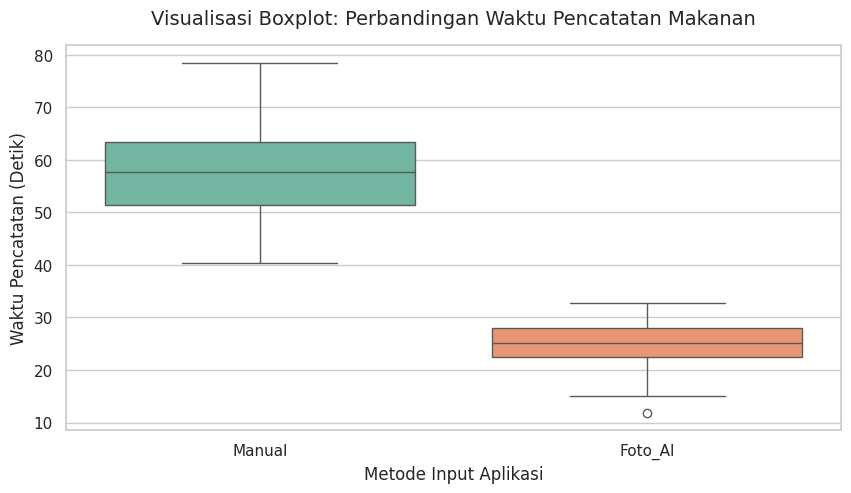

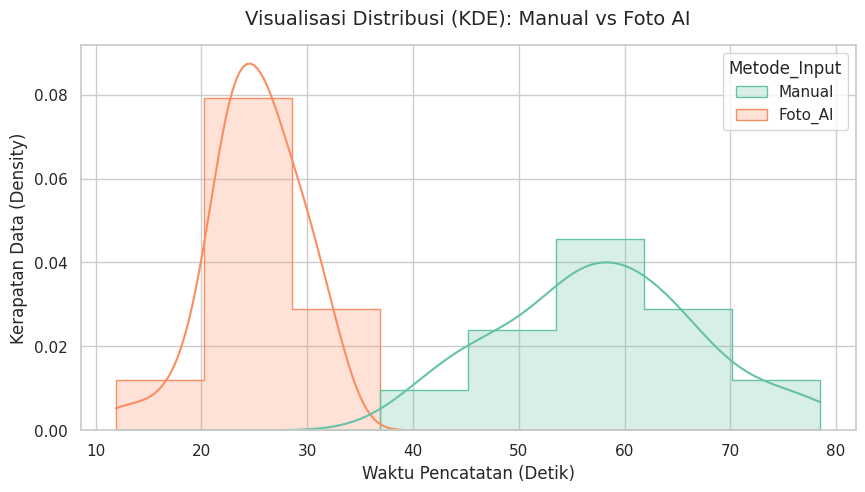

In [7]:
# Set tema visualisasi agar rapi dan bersih
sns.set_theme(style="whitegrid")

# 1. MEMBUAT BOXPLOT
plt.figure(figsize=(10, 5))
sns.boxplot(x='Metode_Input', y='Waktu_Pencatatan_Detik', data=df_eksperimen, palette='Set2')
plt.title('Visualisasi Boxplot: Perbandingan Waktu Pencatatan Makanan', fontsize=14, pad=15)
plt.xlabel('Metode Input Aplikasi', fontsize=12)
plt.ylabel('Waktu Pencatatan (Detik)', fontsize=12)
plt.show()

# 2. MEMBUAT HISTOGRAM / DISTRIBUSI KURVA
plt.figure(figsize=(10, 5))
sns.histplot(data=df_eksperimen, x='Waktu_Pencatatan_Detik', hue='Metode_Input', kde=True, element='step', stat='density', common_norm=False, palette='Set2')
plt.title('Visualisasi Distribusi (KDE): Manual vs Foto AI', fontsize=14, pad=15)
plt.xlabel('Waktu Pencatatan (Detik)', fontsize=12)
plt.ylabel('Kerapatan Data (Density)', fontsize=12)
plt.show()

Uji Statistik (A/B Testing) Atas Data Tersebut

In [9]:
# Pisahkan kembali data berdasarkan kelompok metode input
waktu_manual = df_eksperimen[df_eksperimen['Metode_Input'] == 'Manual']['Waktu_Pencatatan_Detik']
waktu_ai = df_eksperimen[df_eksperimen['Metode_Input'] == 'Foto_AI']['Waktu_Pencatatan_Detik']

# Langkah 1: Uji Normalitas (Shapiro-Wilk)
_, p_norm_manual = stats.shapiro(waktu_manual)
_, p_norm_ai = stats.shapiro(waktu_ai)

print(f"P-Value Normalitas Manual: {p_norm_manual:.4f}")
print(f"P-Value Normalitas Foto AI: {p_norm_ai:.4f}")

# Langkah 2: Jalankan Independent T-Test jika p_norm > 0.05 (Data Normal)
if p_norm_manual > 0.05 and p_norm_ai > 0.05:
    t_stat, p_val_ab = stats.ttest_ind(waktu_manual, waktu_ai, equal_var=True)
    print(f"\nHasil T-Test -> T-Statistic: {t_stat:.4f}, P-Value: {p_val_ab:.4e}")
else:
    # Jika tidak normal, gunakan uji non-parametrik
    u_stat, p_val_ab = stats.mannwhitneyu(waktu_manual, waktu_ai)
    print(f"\nHasil Mann-Whitney U -> U-Statistic: {u_stat:.4f}, P-Value: {p_val_ab:.4e}")

P-Value Normalitas Manual: 0.6722
P-Value Normalitas Foto AI: 0.2616

Hasil T-Test -> T-Statistic: 22.3984, P-Value: 2.4822e-40


**Insight**


*   **Signifikansi Statistik yang Sangat Tinggi**: Nilai P-Value tersebut jauh lebih kecil dari $\alpha = 0.05$ ($2.48 \times 10^{-40} < 0.05$). Oleh karena itu, kita memiliki bukti empiris yang sangat masif untuk menolak Hipotesis Nol ($H_0$) dan menerima Hipotesis Alternatif ($H_1$).

*   **Perbedaan yang Nyata**: Nilai T-Statistic yang positif dan sangat besar (22.3984) menunjukkan adanya perbedaan rata-rata (mean) yang sangat ekstrem dan signifikan antara kedua metode tersebut. Kelompok Manual memerlukan waktu yang jauh lebih lama secara konsisten dibandingkan kelompok Foto AI.

